# Enhanced Odor Complaint Analysis Pipeline

A reusable, minimally styled notebook that reproduces the analytical framework from the paper while remaining adaptable to new datasets.

Analyses included:

1. Data validation and QA
2. Temporal trends (year, month, weekday, hour)
3. Seasonal analysis
4. District-level analysis
5. District vs citywide trend comparison
6. Weekday vs weekend analysis
7. Meteorological correlation analysis
8. Linear regression analysis
9. PCA analysis
10. Optional GIS/shapefile hotspot mapping
11. Automated export of figures and tables


In [2]:
# ==============================================================================
# 1. IMPORT LIBRARIES & CONFIGURE ENVIRONMENT
# ==============================================================================

# Core libraries for data manipulation and analysis
import pandas as pd
import numpy as np

# Plotting and visualization libraries
import matplotlib.pyplot as plt
from pathlib import Path

# Scientific and statistical computation
from scipy.stats import pearsonr

# Machine learning and preprocessing utilities from Scikit-Learn
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

# Configure the output directory for storing generated visualizations and reports
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# Define file constants for datasets (will load from sample data below)
COMPLAINT_FILE = "complaints.csv"
MET_FILE = "meteorology.csv"


## Load Data

In [6]:
# ==============================================================================
# 2. LOAD DATASETS
# ==============================================================================

# Load sample odor complaints and meteorological data from CSV files
complaints = pd.read_csv("sample_complaints.csv")
meteorology = pd.read_csv("sample_meteorology.csv")

# Convert the 'date' columns to datetime objects for temporal indexing and analysis
complaints["date"] = pd.to_datetime(complaints["date"])
meteorology["date"] = pd.to_datetime(meteorology["date"])

# Display the dimensions of the loaded dataframes to confirm successful ingestion
print("Complaints shape:", complaints.shape)
print("Meteorology shape:", meteorology.shape)


(1830, 4)
(366, 11)



## Column Standardization (Recommended)

If your datasets use different column names, edit the mappings below.

Example:

- ReportDate → date
- Borough → district
- NumComplaints → complaints

After this step, the rest of the notebook uses standardized column names and does not need to be modified.


In [7]:
# ==============================================================================
# 3. COLUMN STANDARDIZATION & RENAMING
# ==============================================================================
# Mappings to rename columns if the raw datasets deviate from standard schema.
# Customize these dictionaries as needed for your target datasets.

COMPLAINT_COLUMN_MAP = {
    # 'ReportDate': 'date',
    # 'Borough': 'district',
    # 'NumComplaints': 'complaints',
    # 'HourReported': 'hour',
}

METEOROLOGY_COLUMN_MAP = {
    # 'Temp_C': 'temperature',
    # 'Pressure_hPa': 'atmospheric_pressure',
    # 'RH': 'relative_humidity',
    # 'WindSpeed': 'wind_speed',
}

# Apply the column name mappings using the rename function
complaints = complaints.rename(columns=COMPLAINT_COLUMN_MAP)
meteorology = meteorology.rename(columns=METEOROLOGY_COLUMN_MAP)

# Print standardized columns
print("Complaint columns:")
print(complaints.columns.tolist())

print("\nMeteorology columns:")
print(meteorology.columns.tolist())


Complaint columns:
['date', 'district', 'complaints', 'hour']

Meteorology columns:
['date', 'temperature', 'dew_point', 'vapor_pressure', 'atmospheric_pressure', 'sunshine_duration', 'solar_radiation', 'precipitation', 'relative_humidity', 'wind_speed', 'wind_direction']


## Data Validation

In [8]:
# ==============================================================================
# 4. DATA QUALITY & INTEGRITY CHECKS
# ==============================================================================

# Assess missing data counts across all variables in both datasets
print("\nComplaint Missing Values:")
print(complaints.isna().sum())

print("\nMeteorology Missing Values:")
print(meteorology.isna().sum())

# Identify duplicate observations to evaluate data collection hygiene
print("\nComplaint Duplicates count:", complaints.duplicated().sum())
print("Meteorology Duplicates count:", meteorology.duplicated().sum())



Complaint Missing Values
date          0
district      0
complaints    0
hour          0
dtype: int64

Meteorology Missing Values
date                    0
temperature             0
dew_point               0
vapor_pressure          0
atmospheric_pressure    0
sunshine_duration       0
solar_radiation         0
precipitation           0
relative_humidity       0
wind_speed              0
wind_direction          0
dtype: int64

Complaint Duplicates: 0
Meteorology Duplicates: 0


## Feature Engineering

In [9]:
# ==============================================================================
# 5. FEATURE ENGINEERING (TEMPORAL ATTRIBUTES)
# ==============================================================================

# Extract temporal components (year, month, and day name) from complaints date
complaints["year"] = complaints["date"].dt.year
complaints["month"] = complaints["date"].dt.month
complaints["weekday"] = complaints["date"].dt.day_name()

def season(month):
    """
    Map a calendar month integer to its meteorological season.
    
    Parameters:
    ----------
    month : int
        Month of the year (1 through 12).
        
    Returns:
    -------
    str
        Meteorological season name ('Spring', 'Summer', 'Fall', or 'Winter').
    """
    if month in [3, 4, 5]:
        return "Spring"
    if month in [6, 7, 8]:
        return "Summer"
    if month in [9, 10, 11]:
        return "Fall"
    return "Winter"

# Group complaints into meteorological seasons using the season helper function
complaints["season"] = complaints["month"].apply(season)

# Identify weekends (Saturday/Sunday) based on dayofweek index (>= 5)
complaints["weekend"] = complaints["date"].dt.dayofweek >= 5


## Annual Trend

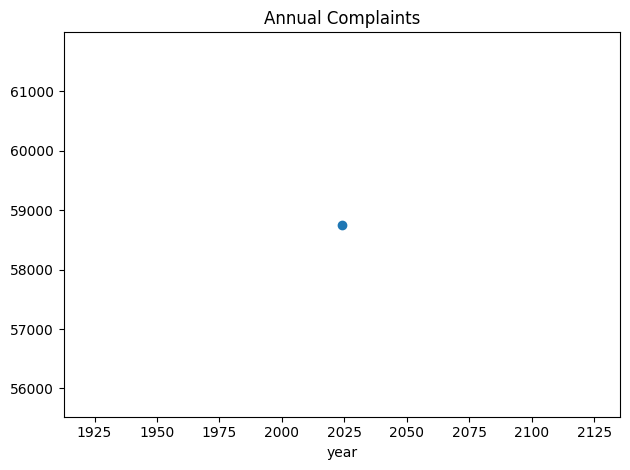

In [10]:
# ==============================================================================
# 6. ANNUAL COMPLAINT TRENDS
# ==============================================================================

# Calculate total complaints aggregated by year
annual = complaints.groupby("year")["complaints"].sum()

# Generate a line plot showing annual odor complaint changes over time
annual.plot(marker="o")
plt.title("Annual Complaints")
plt.xlabel("Year")
plt.ylabel("Number of Complaints")
plt.tight_layout()

# Save the visualization to the output directory and render it inline
plt.savefig(OUTPUT_DIR / "annual_trend.png")
plt.show()


## Monthly Trend

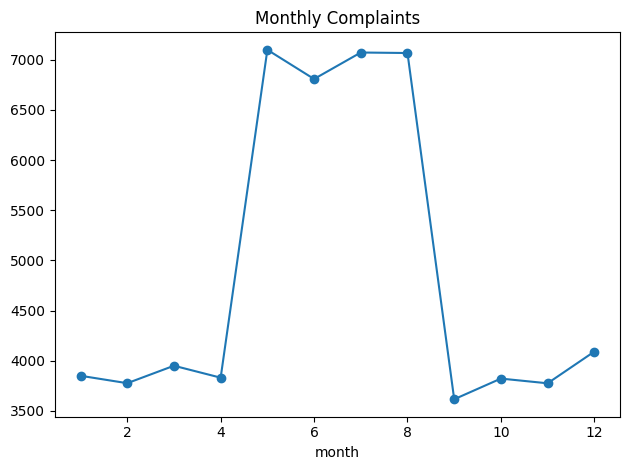

In [11]:
# ==============================================================================
# 7. MONTHLY COMPLAINT TRENDS
# ==============================================================================

# Calculate total complaints aggregated by calendar month
monthly = complaints.groupby("month")["complaints"].sum()

# Generate a line plot showing monthly patterns (seasonality checks)
monthly.plot(marker="o")
plt.title("Monthly Complaints")
plt.xlabel("Month")
plt.ylabel("Number of Complaints")
plt.tight_layout()

# Save the visualization and display
plt.savefig(OUTPUT_DIR / "monthly_trend.png")
plt.show()


## Weekday Trend

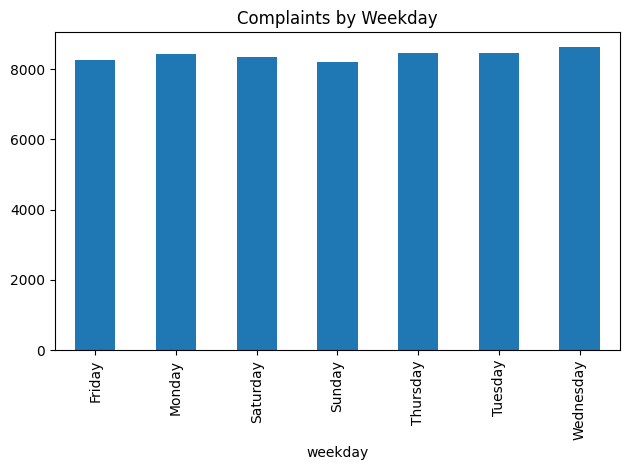

In [12]:
# ==============================================================================
# 8. WEEKDAY COMPLAINT DISTRIBUTION
# ==============================================================================

# Calculate total complaints aggregated by day of the week
weekday = complaints.groupby("weekday")["complaints"].sum()

# Generate a bar plot showing weekly complaint distributions
weekday.plot(kind="bar")
plt.title("Complaints by Weekday")
plt.xlabel("Day of the Week")
plt.ylabel("Number of Complaints")
plt.tight_layout()

# Save the visualization and display
plt.savefig(OUTPUT_DIR / "weekday_trend.png")
plt.show()


## Hourly Trend

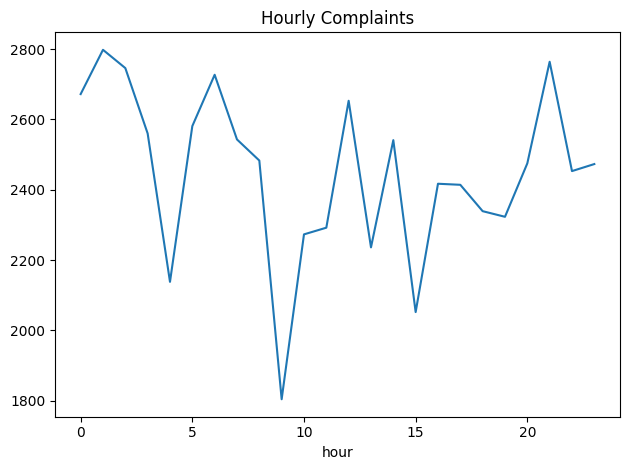

In [13]:
# ==============================================================================
# 9. HOURLY COMPLAINT DISTRIBUTION (IF PRESENT)
# ==============================================================================

# If an hourly reporting column exists, aggregate and plot complaints by hour
if "hour" in complaints.columns:
    hourly = complaints.groupby("hour")["complaints"].sum()
    hourly.plot()
    plt.title("Hourly Complaints")
    plt.xlabel("Hour of Day")
    plt.ylabel("Number of Complaints")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "hourly_trend.png")
    plt.show()
else:
    print("No hour column available.")


## Seasonal Analysis

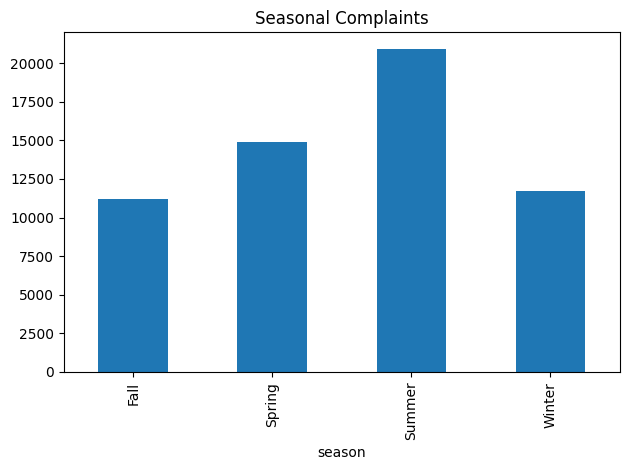

In [14]:
# ==============================================================================
# 10. SEASONAL COMPLAINT DISTRIBUTION
# ==============================================================================

# Aggregate total complaints by meteorological season
seasonal = complaints.groupby("season")["complaints"].sum()

# Generate a bar plot displaying seasonal distribution
seasonal.plot(kind="bar")
plt.title("Seasonal Complaints")
plt.xlabel("Season")
plt.ylabel("Number of Complaints")
plt.tight_layout()

# Save and render the plot
plt.savefig(OUTPUT_DIR / "seasonal_complaints.png")
plt.show()


## District-Level Summary

In [15]:
# ==============================================================================
# 11. DISTRICT-LEVEL COMPLAINT STATISTICS
# ==============================================================================

# Compile descriptive statistics (total, mean, median, std) for each district
district_summary = (
    complaints.groupby("district")["complaints"]
    .agg(["sum", "mean", "median", "std"])
    .sort_values("sum", ascending=False)
)

# Display the summary for the highest-reporting districts
district_summary.head()


,sum,mean,median,std
district,,,,
Central,15245,41.653005,40.0,12.984388
North,13133,35.882514,34.0,12.788260
East,11452,31.289617,30.0,12.486409
South,9826,26.846995,25.0,12.146304
West,9101,24.866120,22.5,12.318873


## District vs Citywide Correlation

In [16]:
# ==============================================================================
# 12. DISTRICT-VS-CITY MONTHLY CORRELATIONS
# ==============================================================================

# Establish a city-wide monthly complaints benchmark baseline
city_monthly = complaints.groupby("month")["complaints"].sum()

results = []

# Loop over each unique district to compute its alignment with city-wide trends
for district in complaints["district"].unique():
    d = complaints[complaints["district"] == district]
    district_monthly = d.groupby("month")["complaints"].sum()
    
    # Outer join to align months, filling missing observations with zero
    merged_data = pd.concat([city_monthly, district_monthly], axis=1).fillna(0)
    merged_data.columns = ["city", "district"]
    
    # Calculate simple regression slope and coefficient of determination (R2)
    if len(merged_data) > 2:
        slope = np.polyfit(merged_data["city"], merged_data["district"], 1)[0]
        r = np.corrcoef(merged_data["city"], merged_data["district"])[0, 1]
        results.append([district, slope, r**2])

# Construct a dataframe summarizing the district-to-city correlation parameters
district_correlations = pd.DataFrame(
    results,
    columns=["district", "slope", "R2"]
).sort_values("R2", ascending=False)

district_correlations.head()


,district,slope,R2
0,North,0.205163,0.983909
1,South,0.194281,0.983619
2,East,0.200962,0.982695
3,West,0.197880,0.975458
4,Central,0.201715,0.966040


## Merge Complaints and Meteorology

In [17]:
# ==============================================================================
# 13. DATA MERGING: COMPLAINTS & METEOROLOGY
# ==============================================================================

# Group and sum complaint counts by date
daily_complaints = (
    complaints.groupby("date")["complaints"]
    .sum()
    .reset_index()
)

# Perform an inner join on date to combine daily complaints with weather factors
merged = daily_complaints.merge(
    meteorology,
    on="date",
    how="inner"
)

# Preview the combined daily dataframe
merged.head()


,date,complaints,temperature,dew_point,vapor_pressure,atmospheric_pressure,sunshine_duration,solar_radiation,precipitation,relative_humidity,wind_speed,wind_direction
0,2024-01-01,134,11.595573,4.761681,17.066959,1005.805166,6.000000,12.000000,0.633760,49.411610,1.620362,209.572129
1,2024-01-02,109,14.280929,10.935018,17.353414,1002.899330,6.068853,12.137707,1.950927,49.212433,5.361927,128.437377
2,2024-01-03,141,14.187670,10.831196,18.334982,1010.123163,6.137686,12.275373,0.363704,42.850119,1.792898,59.137362
3,2024-01-04,126,17.723226,10.819394,19.435300,999.210873,6.206479,12.412957,0.214031,69.389922,7.042959,181.338996
4,2024-01-05,137,13.795760,6.213369,15.376283,1008.946011,6.275210,12.550419,0.138195,82.017409,5.098372,298.873038


## Weekday vs Weekend Split

In [18]:
# ==============================================================================
# 14. WEEKDAY VS. WEEKEND DATAFRAME SPLITTING
# ==============================================================================

# Tag weekends using datetime dayofweek (5 is Saturday, 6 is Sunday)
merged["weekend"] = merged["date"].dt.dayofweek >= 5

# Split the combined dataset to evaluate weekday/weekend behavior separately
weekday_data = merged[~merged["weekend"]]
weekend_data = merged[merged["weekend"]]

# Output the sizes of each subset to verify balance
print("Weekdays dataset size (N):", len(weekday_data))
print("Weekends dataset size (N):", len(weekend_data))


Weekdays: 262
Weekends: 104


## Pearson Correlation Analysis

In [19]:
# ==============================================================================
# 15. WEATHER VARIABLES CORRELATION ANALYSIS
# ==============================================================================

# Predefined list of meteorological columns to correlate against complaints
variables = [
    "temperature",
    "precipitation",
    "wind_speed",
    "wind_direction",
    "dew_point",
    "relative_humidity",
    "vapor_pressure",
    "atmospheric_pressure",
    "sunshine_duration",
    "solar_radiation"
]

def correlation_table(df):
    """
    Calculate Pearson correlation coefficients and p-values between
    odor complaints and a predefined list of weather variables.
    
    Parameters:
    ----------
    df : pandas.DataFrame
        Dataframe containing a 'complaints' column and meteorological features.
        
    Returns:
    -------
    pandas.DataFrame
        A dataframe summarizing correlation and p-value metrics sorted in descending order.
    """
    rows = []

    for v in variables:
        # Compute Pearson correlation coefficient (r) and two-tailed p-value
        r, p = pearsonr(df["complaints"], df[v])
        rows.append([v, r, p])

    return pd.DataFrame(
        rows,
        columns=["Variable", "Correlation", "PValue"]
    ).sort_values("Correlation", ascending=False)

# Compute correlations separately for weekdays and weekends
weekday_corr = correlation_table(weekday_data)
weekend_corr = correlation_table(weekend_data)

# Render the weekday correlation table
weekday_corr


,Variable,Correlation,PValue
5,relative_humidity,0.035430,0.568058
6,vapor_pressure,0.027366,0.659266
4,dew_point,0.017919,0.772824
8,sunshine_duration,0.017860,0.773548
9,solar_radiation,0.017860,0.773548
0,temperature,0.017723,0.775246
7,atmospheric_pressure,0.012013,0.846544
3,wind_direction,0.007242,0.907133
1,precipitation,-0.042230,0.496129
2,wind_speed,-0.124024,0.044893


## Export Correlation Tables

In [20]:
# ==============================================================================
# 16. SAVE CORRELATION TABLES
# ==============================================================================

# Save correlation outputs to CSV files in the outputs directory
weekday_corr.to_csv(
    OUTPUT_DIR / "weekday_correlations.csv",
    index=False
)

weekend_corr.to_csv(
    OUTPUT_DIR / "weekend_correlations.csv",
    index=False
)


## Linear Regression Models

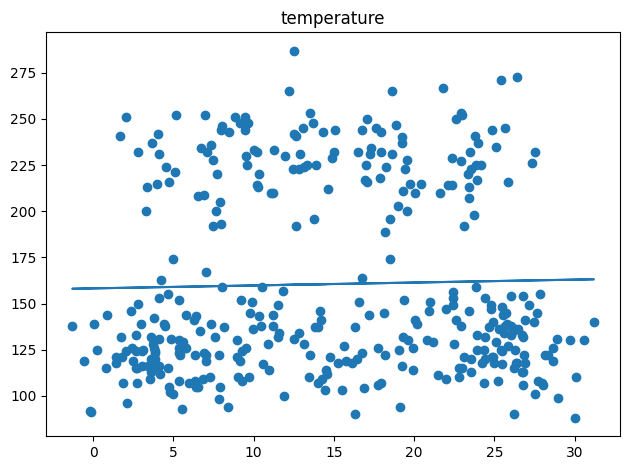

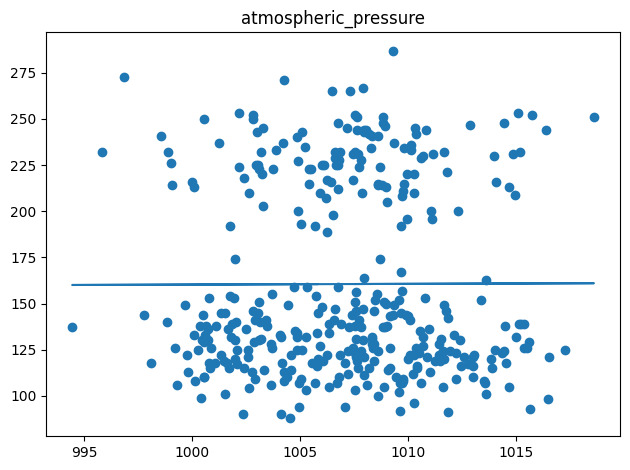

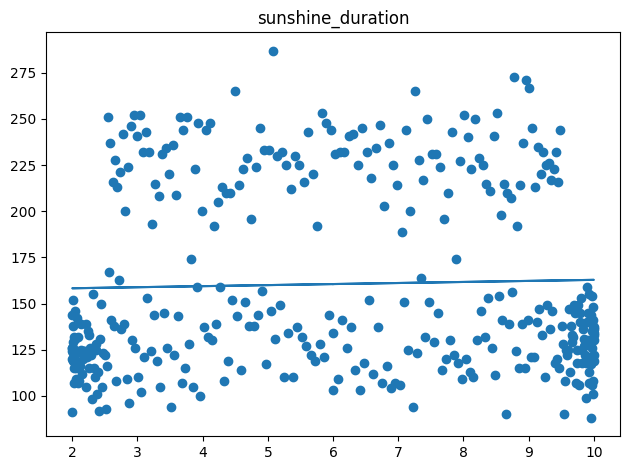

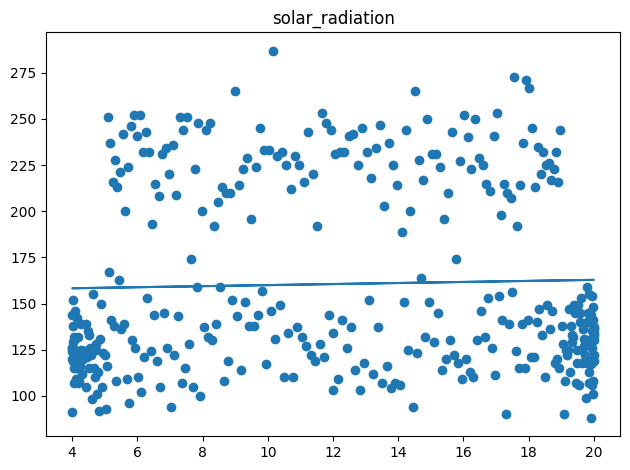

,Variable,Coefficient,Intercept,R2
0,temperature,0.157842,158.200309,0.000711
1,atmospheric_pressure,0.039707,120.548803,0.000012
2,sunshine_duration,0.569853,157.119130,0.000991
3,solar_radiation,0.284927,157.119130,0.000991


In [21]:
# ==============================================================================
# 17. SINGLE VARIABLE LINEAR REGRESSIONS
# ==============================================================================

# Key meteorological variables to model independently
key_variables = [
    "temperature",
    "atmospheric_pressure",
    "sunshine_duration",
    "solar_radiation"
]

regression_results = []

# Fit simple linear regression models and plot scatter plots with best-fit lines
for var in key_variables:
    X = merged[[var]]
    y = merged["complaints"]

    # Initialize and fit the Scikit-Learn linear regression model
    model = LinearRegression()
    model.fit(X, y)

    # Compute R-squared statistic
    r2 = model.score(X, y)
    regression_results.append([var, model.coef_[0], model.intercept_, r2])

    # Plot complaints vs the weather variable
    plt.scatter(X, y, alpha=0.6, label='Daily Data')
    plt.plot(X, model.predict(X), color='red', linewidth=2, label='Regression Line')
    plt.title(f"Regression: {var.replace('_', ' ').title()} vs Complaints")
    plt.xlabel(var.replace('_', ' ').title())
    plt.ylabel("Complaints")
    plt.legend()
    plt.tight_layout()
    
    # Save each scatter regression plot
    plt.savefig(OUTPUT_DIR / f"regression_{var}.png")
    plt.show()

# Display regression parameters in a summary dataframe
pd.DataFrame(
    regression_results,
    columns=["Variable", "Coefficient", "Intercept", "R2"]
)


## Principal Component Analysis

[0.49829898 0.1042355 ]


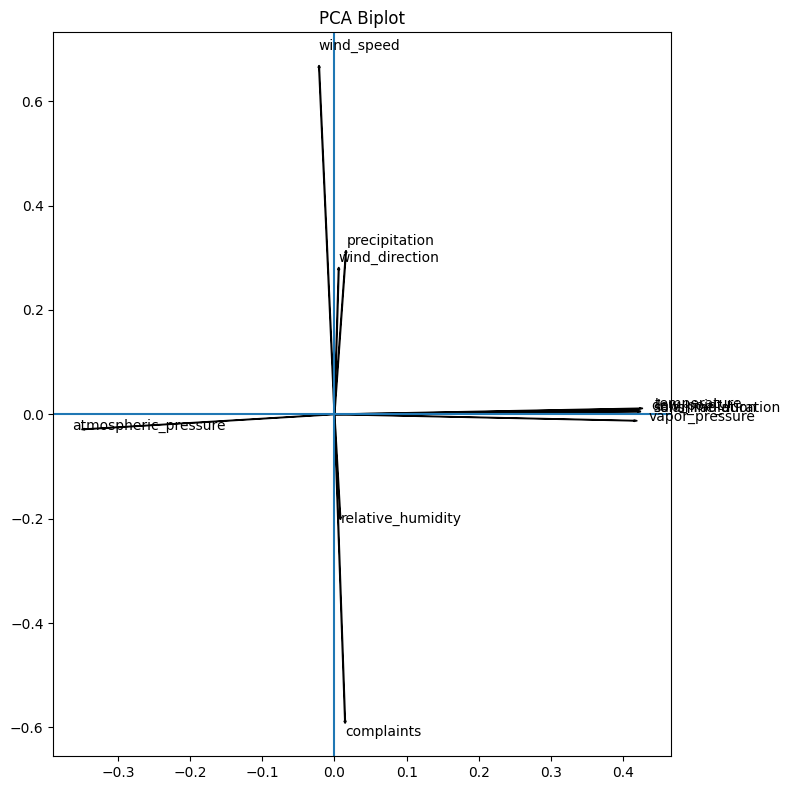

,PC1,PC2
complaints,0.014676,-0.587650
temperature,0.422924,0.011317
dew_point,0.418260,0.008778
vapor_pressure,0.415150,-0.012148
atmospheric_pressure,-0.346150,-0.028519
sunshine_duration,0.420123,0.005414
solar_radiation,0.420123,0.005414
precipitation,0.015810,0.309824
relative_humidity,0.008078,-0.197305
wind_speed,-0.021287,0.664455


In [22]:
# ==============================================================================
# 18. MULTIVARIATE PRINCIPAL COMPONENT ANALYSIS (PCA)
# ==============================================================================

# Columns to include in PCA decomposition
pca_columns = [
    "complaints",
    "temperature",
    "dew_point",
    "vapor_pressure",
    "atmospheric_pressure",
    "sunshine_duration",
    "solar_radiation",
    "precipitation",
    "relative_humidity",
    "wind_speed",
    "wind_direction"
]

# Drop rows containing missing values in the PCA columns
pca_df = merged[pca_columns].dropna()

# Standardize variables to mean=0 and variance=1 (standard scaler required for PCA)
scaled = StandardScaler().fit_transform(pca_df)

# Fit a 2-component PCA model
pca = PCA(n_components=2)
scores = pca.fit_transform(scaled)

# Retrieve loading vectors mapping features to the first two PCs
loadings = pd.DataFrame(
    pca.components_.T,
    index=pca_columns,
    columns=["PC1", "PC2"]
)

# Output explained variance ratio for each PC
print("Explained variance ratio (PC1, PC2):", pca.explained_variance_ratio_)

# Plot the PCA Loading Biplot
plt.figure(figsize=(8, 8))
for name, row in loadings.iterrows():
    # Highlight complaints loading in red, others in blue
    color = "red" if name == "complaints" else "blue"
    plt.arrow(
        0, 0,
        row["PC1"],
        row["PC2"],
        head_width=0.02,
        color=color
    )
    plt.text(
        row["PC1"] * 1.05,
        row["PC2"] * 1.05,
        name.replace("_", " ").title(),
        color=color
    )

# Add baseline axes and labels
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.title("PCA Biplot of Meteorological Variables & Complaints")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save PCA plot and show loadings table
plt.savefig(OUTPUT_DIR / "pca_biplot.png")
plt.show()

loadings


## Optional GIS Hotspot Mapping

In [23]:
# ==============================================================================
# 19. GEOSPATIAL ANALYSIS & PLOTTING (MOCK WORKFLOW)
# ==============================================================================
# Placeholder workflow showing how GeoPandas could be used to join complaint data
# with district shapefiles for map visualizations. Commented out as libraries/files
# are not active in this environment.

# import geopandas as gpd
#
# districts = gpd.read_file('district_shapefile.shp')
#
# hotspot_data = (
#     complaints.groupby('district')
#     ['complaints']
#     .sum()
#     .reset_index()
# )
#
# districts = districts.merge(
#     hotspot_data,
#     on='district'
# )
#
# districts.plot(
#     column='complaints',
#     legend=True
# )


## Outputs

Generated automatically:

- PNG figures
- Correlation tables (CSV)
- Regression summaries
- PCA outputs

All exports are written to the `outputs/` directory.
